# 06. Explore the climate of cells with records

- Input: `data/pomacea_jp_thinned_30s_climate.csv` (created by `04_WorldClim.ipynb`), `data/wc2.1_30s_bio_{1,6,12}_japan_land.tif` (created by `05_japan_mask.ipynb`)
- Output: `outputs/bio6_hist.png`

- Purpose: Compare the climate of cells with records with that of all land cells in Japan, to see which climatic conditions may limit the distribution.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

# Project folders on Google Drive
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/pomacea"
DATA_DIR = f"{BASE_DIR}/data"

Mounted at /content/drive


In [2]:
!pip install rasterio

In [3]:
import numpy as np
import rasterio

with rasterio.open(f"{DATA_DIR}/wc2.1_30s_bio_6_japan_land.tif") as src:
    band = src.read(1)
    bio6_land = band[band != src.nodata]  # values of land cells in Japan only
print(f"{len(bio6_land):,} land cells in Japan")

548,035 land cells in Japan


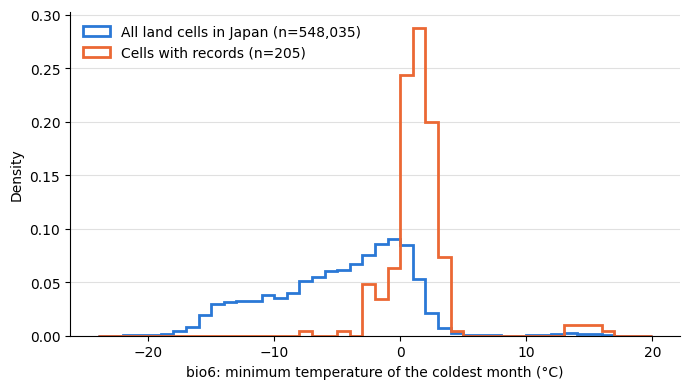

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

pts = pd.read_csv(f"{DATA_DIR}/pomacea_jp_thinned_30s_climate.csv")

bins = np.arange(np.floor(bio6_land.min()), np.ceil(bio6_land.max()) + 1, 1)  # 1 °C bins

fig, ax = plt.subplots(figsize=(7, 4))
# Density (not counts), because the two groups differ in size by more than 1,000 times
ax.hist(bio6_land, bins=bins, density=True, histtype="step", linewidth=2,
        color="#2a78d6", label=f"All land cells in Japan (n={len(bio6_land):,})")
ax.hist(pts["bio6"], bins=bins, density=True, histtype="step", linewidth=2,
        color="#eb6834", label=f"Cells with records (n={len(pts)})")

ax.set_xlabel("bio6: minimum temperature of the coldest month (°C)")
ax.set_ylabel("Density")
ax.grid(axis="y", color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()

plt.savefig(f"{BASE_DIR}/outputs/bio6_hist.png", dpi=150)
plt.show()